Dataset Shape: (8807, 12)
Optimal Alpha found: 0.14563
Lasso RMSE: 22.09 minutes
Lasso R² Score: 0.32


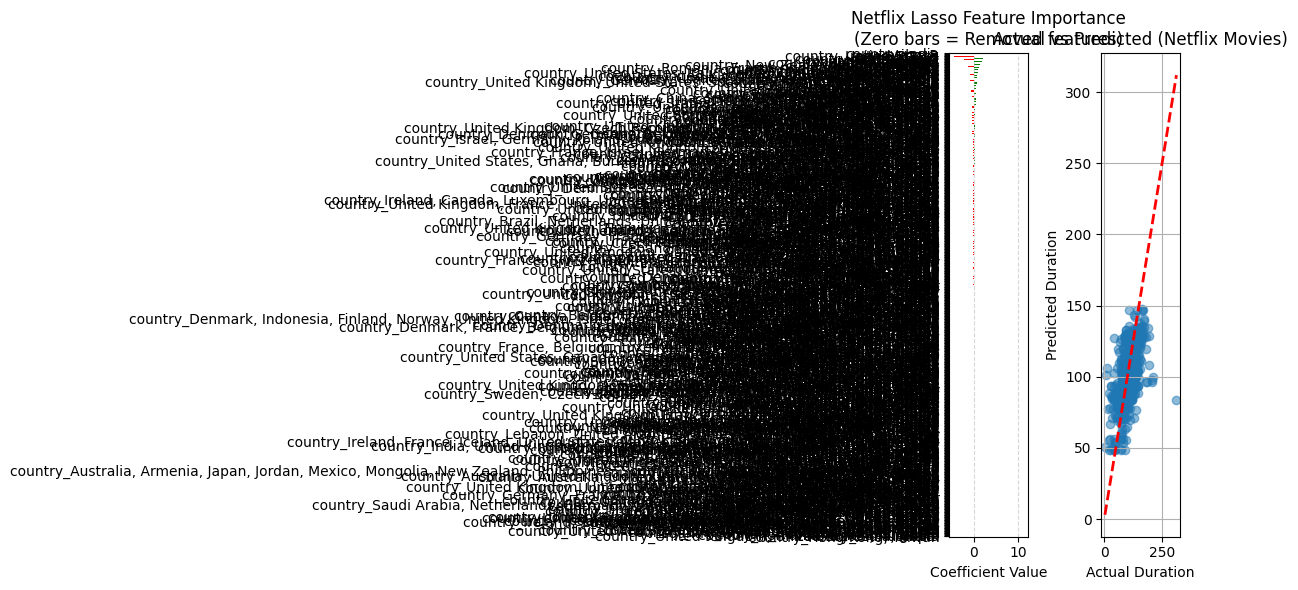


Features eliminated by Lasso (Coeff ≈ 0):
['rating_NR', 'country_Argentina, Brazil, France, Poland, Germany, Denmark', 'country_Argentina, Chile', 'country_Argentina, Chile, Peru', 'country_Argentina, France', 'country_Argentina, Venezuela', 'country_Australia, Armenia, Japan, Jordan, Mexico, Mongolia, New Zealand, Philippines, South Africa, Sweden, United States, Uruguay', 'country_Australia, Canada', 'country_Australia, France', 'country_Australia, India', 'country_Australia, United Arab Emirates', 'country_Australia, United Kingdom', 'country_Australia, United Kingdom, Canada', 'country_Australia, United Kingdom, United Arab Emirates, Canada', 'country_Australia, United Kingdom, United States, New Zealand, Italy, France', 'country_Austria', 'country_Austria, Czech Republic', 'country_Austria, Iraq, United States', 'country_Austria, United States', 'country_Belgium', 'country_Belgium, United Kingdom, United States', 'country_Brazil', 'country_Brazil, India, China, United States', 'c

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ====================================
# LOAD NETFLIX DATASET (FROM COLAB)
# ====================================
df = pd.read_csv("./sample_data/netflix_titles.csv")

print("Dataset Shape:", df.shape)

# ====================================
# DATA PREPROCESSING (DIFFERENT LOGIC)
# ====================================

# Keep only Movies (TV Shows have seasons)
df = df[df['type'] == 'Movie'].copy()

# Convert duration to numeric minutes
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Select useful columns
data = df[['duration_minutes','release_year','rating','country']].copy()

# Drop missing values
data.dropna(inplace=True)

# One-Hot Encoding (different from Life Expectancy dataset)
data = pd.get_dummies(data, columns=['rating','country'], drop_first=True)

# ====================================
# DEFINE FEATURES + TARGET
# ====================================
X = data.drop('duration_minutes', axis=1)
y = data['duration_minutes']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ====================================
# STANDARDIZATION (VERY IMPORTANT FOR LASSO)
# ====================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ====================================
# LASSO WITH AUTOMATIC ALPHA SEARCH
# ====================================
lasso_cv = LassoCV(
    alphas=np.logspace(-4,1,50),
    cv=5,
    random_state=42,
    max_iter=5000
)

lasso_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha found: {lasso_cv.alpha_:.5f}")

# Predictions
y_pred = lasso_cv.predict(X_test_scaled)

# ====================================
# MODEL EVALUATION
# ====================================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Lasso RMSE: {rmse:.2f} minutes")
print(f"Lasso R² Score: {r2:.2f}")

# ====================================
# VISUALIZATION
# ====================================
plt.figure(figsize=(12,6))

# Plot 1: Feature Importance
coefs = pd.Series(lasso_cv.coef_, index=X.columns)
coefs_sorted = coefs.reindex(coefs.abs().sort_values().index)

plt.subplot(1,2,1)
coefs_sorted.plot(kind='barh',
                  color=(coefs_sorted > 0).map({True:'green', False:'red'}))

plt.title("Netflix Lasso Feature Importance\n(Zero bars = Removed features)")
plt.xlabel("Coefficient Value")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Plot 2: Actual vs Predicted
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2
)

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted (Netflix Movies)")
plt.grid(True)

plt.tight_layout()
plt.savefig('netflix_lasso_results.png')
plt.show()

# ====================================
# FEATURES REMOVED BY LASSO
# ====================================
print("\nFeatures eliminated by Lasso (Coeff ≈ 0):")
print(coefs[coefs == 0].index.tolist())
